In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
class Value:
  def __init__(self, data, _children = (), _op ='', label = ''):
    self.data = data
    self.grad = 0
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(a,b):
    b = b if isinstance(b, Value) else Value(b)
    out = Value(a.data+b.data, (a,b), '+')
    def _backward():
      a.grad += 1.0*out.grad
      b.grad += 1.0*out.grad
    out._backward = _backward
    return out

  def __mul__(a,b):
    b = b if isinstance(b, Value) else Value(b)
    out = Value(a.data * b.data, (a,b), '*')
    def _backward():
      a.grad += b.data*out.grad
      b.grad += a.data*out.grad
    out._backward = _backward

    return out

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __radd__(self, other):
    return self + other

  def __rsub__(self, other):
    return other + (-self)

  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')
    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1-t**2)*out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def topo_sort(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          topo_sort(child)
        topo.append(v)
    topo_sort(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [ ]:
from graphviz import Digraph

def trace(node):
  nodes, edges = set(), set()
  def build(root):
    if root not in nodes:
      nodes.add(root)
      for child in root._prev:
        edges.add((child, root))
        build(child)
  build(node)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

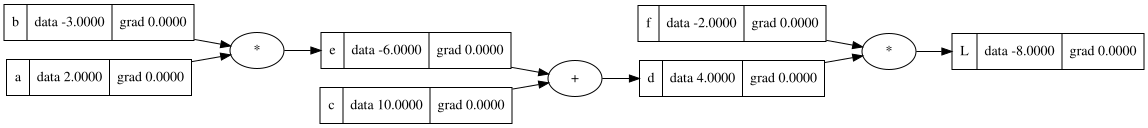

In [ ]:
draw_dot(L)

In [ ]:
d.grad = -2.0
f.grad = 4.0

In [ ]:
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  e.data += h
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

-2.000000000000668


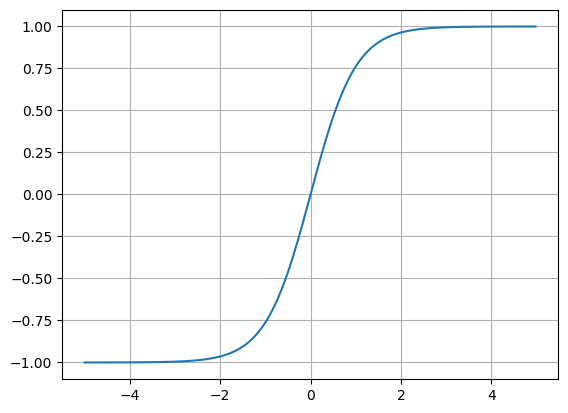

In [ ]:
plt.plot(np.arange(-5,5,0.02), np.tanh(np.arange(-5,5,0.02))); plt.grid();


In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.881317, label = 'b')


x1w1 = x1*w1
x1w1.label = 'x1*w1'
x2w2 = x2*w2
x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'o'



In [ ]:
o.grad = 1.0

In [ ]:
o.backward()

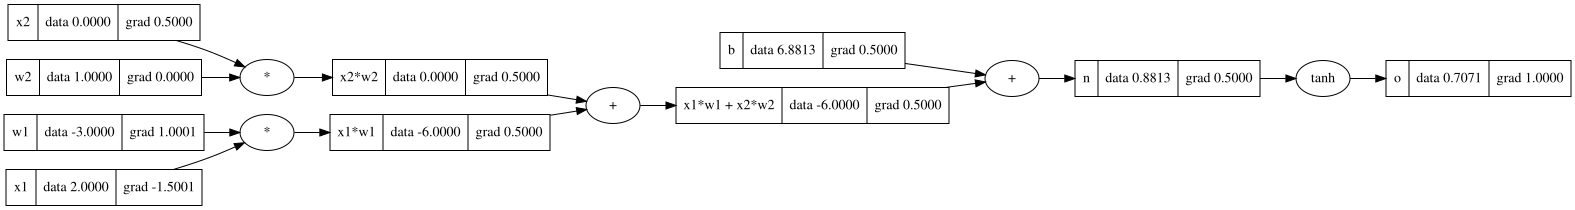

In [ ]:
draw_dot(o)

In [ ]:
a = Value(2)
a+1

Value(data=3)

In [ ]:
import torch
import random

In [ ]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.881317]).double() ; b.requires_grad = True

In [ ]:
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

In [ ]:
o.backward()

In [ ]:
print(x1.grad.item())
print(x2.grad.item())

-1.5001197474179535
0.5000399158059845


In [ ]:
class Neuron:

  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layers:

  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layers(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


x = [2.0,3.0,-1]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.9068118701903195)

In [ ]:
xs = [
     [2.0, 3.0, -1.0],
     [-1.0, 2.0, 3.0]
 ]
ys = [1.0, -1.0]
ypred = []
for i in xs:
  ypred.append(n(i))
ypred

[Value(data=0.9068118701903195), Value(data=0.04357347524924625)]

In [ ]:
loss = sum((yp - ygt)**2 for yp, ygt in zip(ypred, ys))
loss

Value(data=1.097729625781215)

In [ ]:
ypred = []
for i in xs:
  ypred.append(n(i))
ypred
loss = sum((yp - ygt)**2 for yp, ygt in zip(ypred, ys))
loss

Value(data=0.03032413442880721)

In [ ]:
for p in n.parameters():
  p.grad = 0.0
loss.backward()

In [ ]:
for p in n.parameters():
  p.data += -0.1 * p.grad


In [ ]:
for k in range(100):
  ypred = []
  for i in xs:
    ypred.append(n(i))
  ypred
  loss = sum((yp - ygt)**2 for yp, ygt in zip(ypred, ys))
  print(loss)
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  for p in n.parameters():
    p.data += -0.2 * p.grad

Value(data=0.03032413442880721)
Value(data=0.009004985194433324)
Value(data=0.007568830895690784)
Value(data=0.006646912189215854)
Value(data=0.00598017638109696)
Value(data=0.005464591824812499)
Value(data=0.005048381848785146)
Value(data=0.004702190023616634)
Value(data=0.004407826372692706)
Value(data=0.00415326707090509)
Value(data=0.003930163115119125)
Value(data=0.0037324883424846387)
Value(data=0.003555755278246571)
Value(data=0.0033965353764925537)
Value(data=0.003252152328448679)
Value(data=0.0031204786753883983)
Value(data=0.002999796659607172)
Value(data=0.0028887004400886852)
Value(data=0.002786025759579052)
Value(data=0.002690798315288472)
Value(data=0.002602195171514608)
Value(data=0.0025195154548935707)
Value(data=0.0024421577787118666)
Value(data=0.0023696026260270463)
Value(data=0.0023013984416612432)
Value(data=0.002237150535746815)
Value(data=0.002176512144852283)
Value(data=0.0021191771674625116)
Value(data=0.002064874212220137)
Value(data=0.0020133616851951064)
Val

In [ ]:
ypred

[Value(data=0.9841578137743389), Value(data=-0.9778797782971048)]